In [16]:
# import necessary libraries

import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt

# create url for dataset
url ="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

# load the Csv dataframe
data = pd.read_csv(url)

## ** Understanding the MPG Dataset in Summary**

**Source:** [Seaborn Sample Data – mpg.csv](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv)
**Origin:** Adapted from the classic *Auto MPG dataset* (UCI Machine Learning Repository).
**Purpose:** To explore relationships between car features and fuel efficiency (miles per gallon).

**Gallon is a unit of liquid measurement**

---

### **Overview**

This dataset contains information about various car models from the 1970s and early 1980s.
Each record represents one car and includes details on its performance, size, and origin.
It is widely used for **exploratory data analysis**, **regression modeling**, and **data visualization** exercises.

---

### **Variables**

| Column           | Description                                            |
| ---------------- | ------------------------------------------------------ |
| **mpg**          | Fuel efficiency in miles per gallon (target variable). |
| **cylinders**    | Number of engine cylinders.                            |
| **displacement** | Engine displacement (cubic inches).                    |
| **horsepower**   | Engine power.                    |
| **weight**       | Vehicle weight (pounds).                               |
| **acceleration** | Time to accelerate from 0–60 mph (seconds).            |
| **model_year**   | Year the model was produced.                           |
| **origin**       | Region of origin: USA, Europe, or Japan.               |
| **name**         | Car model name.                                        |

---

### **Key Insights**

* Contains both **numerical** and **categorical** variables — suitable for mixed-type data analysis.
* Common tasks include:

  * Predicting `mpg` using other features (regression).
  * Visualizing how `mpg` varies by `weight`, `horsepower`, or `origin`.
  * Studying trends in fuel efficiency across `model_year`.
* Data requires light cleaning (e.g., handling missing `horsepower` values).

---

### **Notes**

* Units are in U.S. customary measures (mpg, pounds, cubic inches).
* Cars mostly from **1970–1982**, so results reflect that era’s automotive context.
* Ideal for learning **data visualization (Seaborn)**, **correlation analysis**, and **model training**.

In [11]:
# display the head
display(data.head())



,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [12]:
df = data.copy(deep=True)

In [13]:
# display some statistics

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  


In [14]:
# display the missing values 
print(df.isna().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [15]:
# show the duplicate values

print(df.duplicated().sum())

0


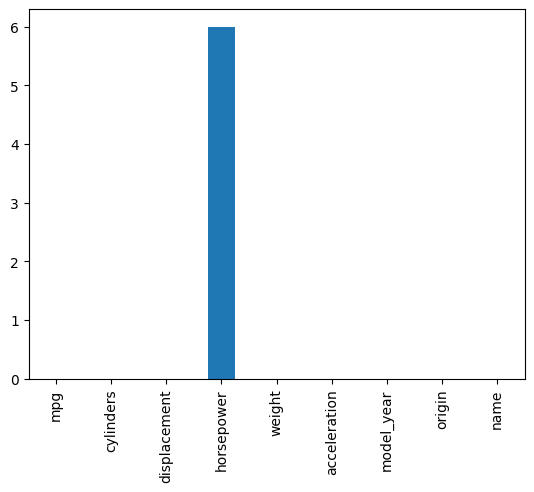

In [19]:
# plot the missing value to see them on var chat

df.isna().sum().plot(kind='bar')
plt.show()

In [20]:
df['horsepower'].fillna(method='ffill', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3116\3283328991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(method='ffill', inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_3116\3283328991.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['horsepower'].fillna(method='ffill', inplace=True)


In [22]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

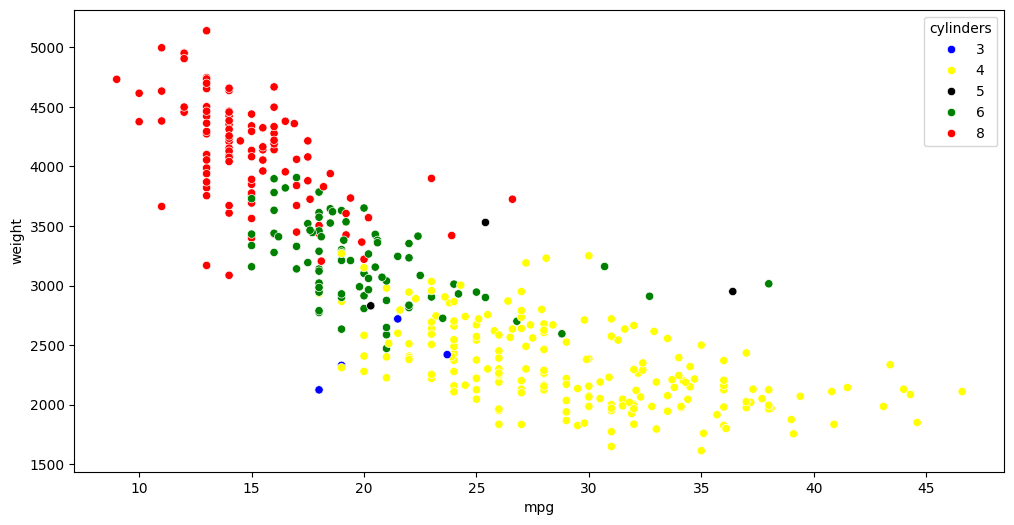

In [52]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, 
                x="mpg", 
                y="weight",
                hue="cylinders",
                # hue="origin",
                palette=['blue', 'yellow', 'black', 'green', 'red'] 
               )
# make the regression line
# sns.regplot(data=df,  x="mpg", y="weight")
plt.show()

<Axes: xlabel='cylinders', ylabel='mpg'>

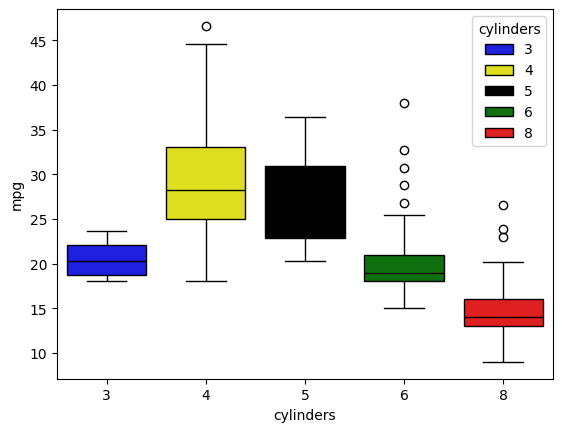

In [57]:


# make a boxplot to get the best car You can buy accordingly . like maybbe when you are economic, you need car that can move many miles per gallon

sns.boxplot(data=df, x="cylinders", y="mpg", hue="cylinders", palette=['blue', 'yellow', 'black', 'green', 'red'] )

The cars with 4 cylinders are the one that can move many miles per gallon. when you are economic: this is the deal on these type of cars with 4 cylinders

In [58]:
df['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [62]:
counts_japan = df[df['origin']=='usa'].value_counts()
print(counts_japan)

mpg   cylinders  displacement  horsepower  weight  acceleration  model_year  origin  name                             
9.0   8          304.0         193.0       4732    18.5          70          usa     hi 1200d                             1
10.0  8          307.0         200.0       4376    15.0          70          usa     chevy c20                            1
                 360.0         215.0       4615    14.0          70          usa     ford f250                            1
11.0  8          318.0         210.0       4382    13.5          70          usa     dodge d200                           1
                 350.0         180.0       3664    11.0          73          usa     oldsmobile omega                     1
                                                                                                                         ..
36.0  4          135.0         84.0        2370    13.0          82          usa     dodge charger 2.2                    1
36.1  4      

<Axes: xlabel='origin', ylabel='count'>

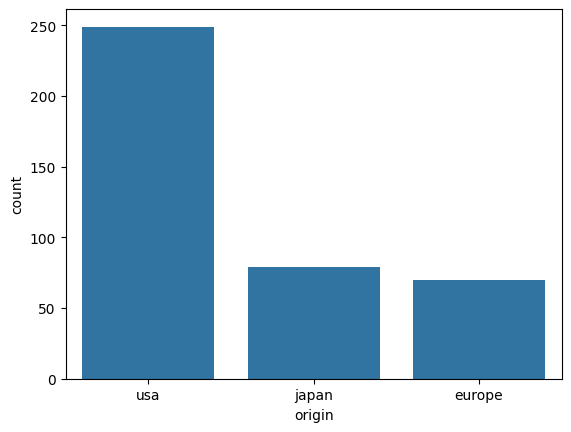

In [61]:
sns.countplot(data=df, x='origin')

In [63]:
df.columns


Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [65]:
corr_ = df[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year']].corr()

In [66]:

# very important visual in report, especial when reporting to other data scientist
corr_

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.777685,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842627,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897192,0.932824,-0.543684,-0.370164
horsepower,-0.777685,0.842627,0.897192,1.000000,0.864040,-0.686334,-0.417302
weight,-0.831741,0.896017,0.932824,0.864040,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.686334,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.417302,-0.306564,0.288137,1.000000


<Axes: >

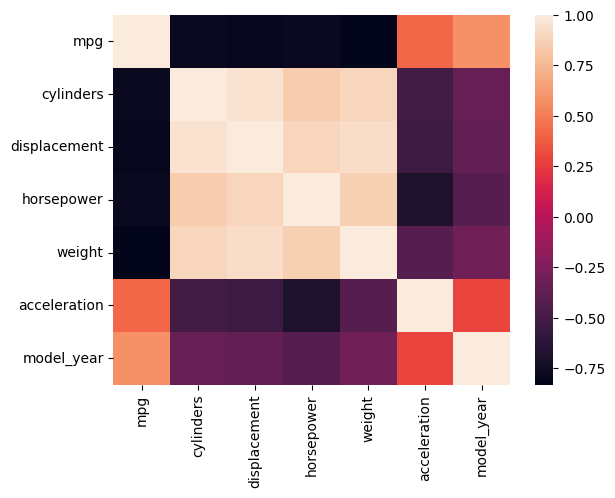

In [68]:

# very important visual in report, especial when reporting to other data scientist
sns.heatmap(corr_)

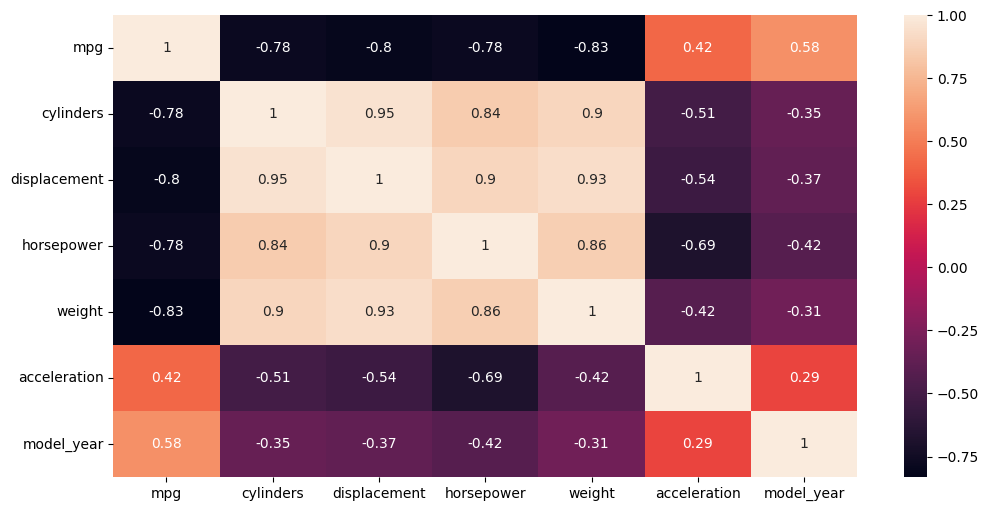

In [70]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_, annot=True)
# color gradients — where colors represent the magnitude or intensity of the data
# annotation put the correlation value inside the colors
plt.show()